### Largest Rectangle in Histogram (Hard)

Given an array of integers heights representing the histogram's bar height where the width of each bar is 1, return the area of the largest rectangle in the histogram.

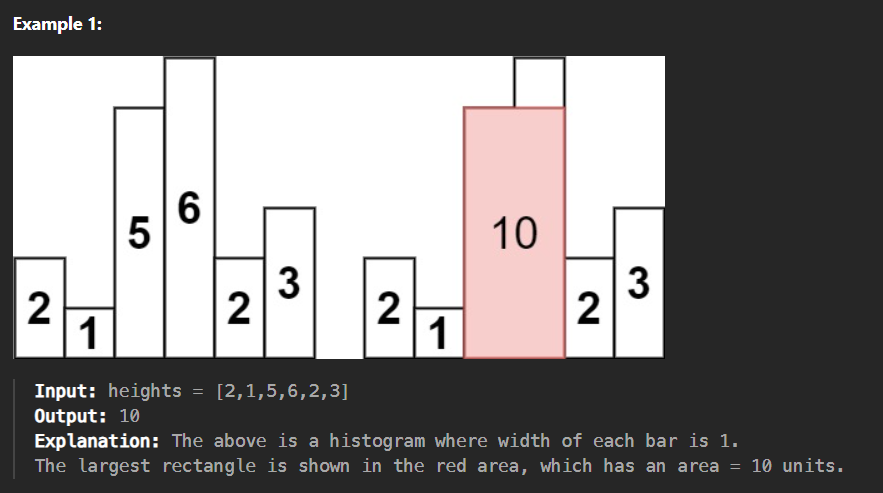

In [1]:
from typing import List

Brute Force Approach

In [ ]:
class Solution:
    def largestRectangleArea(self, heights: list[int]) -> int:

        # we make an area array
        area = [0]*len(heights)

        # for each bar in a histogram, we try to find its maximum area depending on its height and width

        for i in range(len(heights)):

            height = heights[i]
            width = 1 

            # we assign fresh pointers to the left and right of i
            # this is done so we can explore how much width can be added

            # left exploration
            lp = i-1

            while lp>=0 and height <= heights[lp]:
                width += 1
                lp -= 1

            # right exploration
            rp = i+1

            while rp<=len(heights)-1 and height <= heights[rp]:
                width += 1
                rp += 1

            area[i] = height*width

        return max(area)

In [8]:
s = Solution()
result = s.largestRectangleArea([2,4])
print(result)

4


Monotonic Stack Approach

In [2]:
# when stack[-1] < val we push
# when stack[-1] > val we pop, we have to find a way to count the number of pops

class Solution:
    def largestRectangleArea(self, heights: list[int]) -> int:

        areas = [0]*len(heights)
        stack : list[tuple[int, int]] = [] #stack with (index, val) tuples

        for idx, val in enumerate(heights):

            # condition to remove from the stack
        
            while stack and stack[-1][1] > val:
                popped_idx, popped_val = stack.pop()
                # the popped value is the height
                # how to get the width
                left = stack[-1][0] if stack else -1
                right = idx
                width = right - left - 1

                areas[popped_idx] = popped_val * width
            # otherwise if stack[-1] < val, we push into the stack
            stack.append((idx, val))

        while stack:
            popped_idx, popped_val = stack.pop()
            left = stack[-1][0] if stack else -1
            right = len(heights)
            width = right - left - 1
            areas[popped_idx] = popped_val * width
        return max(areas)

 